In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 16
n_actions = 4
goal_state = 15

Q_table = np.zeros((n_states, n_actions))


In [2]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000


In [3]:
def get_next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and col > 0:
        col -= 1
    elif action == 1 and col < 3:
        col += 1
    elif action == 2 and row > 0:
        row -= 1
    elif action == 3 and row < 3:
        row += 1

    return row * 4 + col


In [4]:
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state


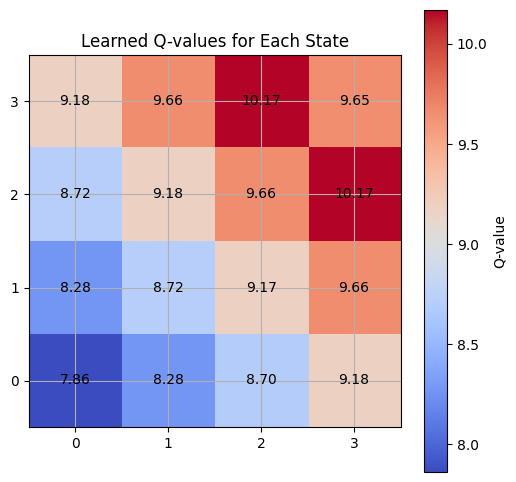

Learned Q-table:
[[ 7.28944366  7.86256429  7.2311919   7.71440461]
 [ 7.30008954  7.94502775  0.          8.27674729]
 [ 7.78294405  8.63888951  6.60262576  8.69800004]
 [ 7.94584692  8.64794731  8.51453494  9.17548937]
 [ 7.61850805  8.10328949  7.33485574  8.27523491]
 [ 7.78574324  8.15281093  7.82830144  8.71845427]
 [ 8.23004767  9.15419424  8.24771458  9.17003384]
 [ 8.64548263  9.12219333  8.69638886  9.6604635 ]
 [ 8.23719141  8.7102215   7.67187542  8.71700872]
 [ 8.25291405  9.1605593   8.27337888  9.17761753]
 [ 8.70119655  9.65922803  8.68190493  9.63763312]
 [ 9.15286028  9.64669122  9.15563906 10.16910776]
 [ 8.69119954  9.17760929  8.08736099  8.70061119]
 [ 8.71736494  9.66065461  8.71645826  9.17525408]
 [ 9.17688337 10.16911012  9.15518163  9.58275843]
 [ 9.65169486  8.87250435  7.69529126  8.79013487]]


In [5]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)
